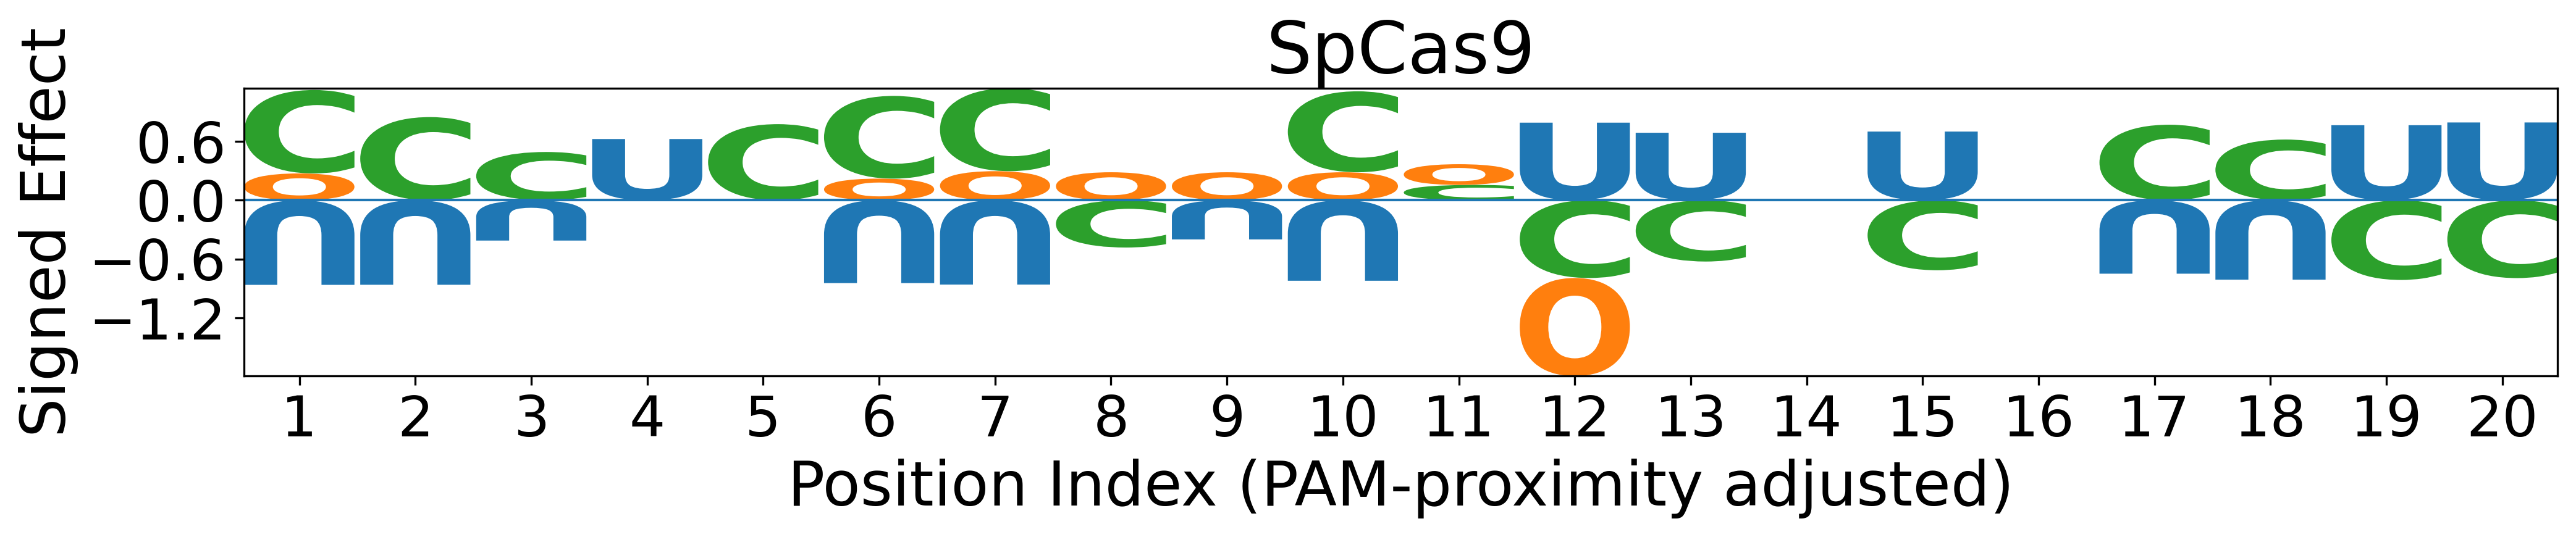

Saved to: SpCas9_Specificity_model_computed_spearman_by_struct_position_spacer.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

STRUCT_MAP = {
    # common possibilities (edit to match your file) since Cas9 and 3' PAM, the symbols are reversed:
    "Unpaired": "U",
    "Paired-Opening": "C",
    "Paired-Closing": "O"
}

def load_logo_matrix(csv_path, value_col="Median Spearman Correlation", pos_max=100):
    df = pd.read_csv(csv_path)
    df[['Pos', 'Raw']] = df['Feature'].str.extract(r'Pos(\d+)_(.+)')
    df['Pos'] = df['Pos'].astype(int)
    df["Raw"] = df["Raw"].astype(str).str.strip()
    # Map Raw token -> dot-paren symbol
    df["Struct"] = df["Raw"].map(STRUCT_MAP)
    mat = df.pivot(index="Struct", columns="Pos", values=value_col)
    mat = mat.reindex(columns=range(1, pos_max + 1))

    return mat

# ---- Load positive and negative matrices ----
pos_mat = load_logo_matrix("features_with_positive_IQR_Specificity_model_cnn2_Cas9.csv")
neg_mat = load_logo_matrix("features_with_negative_IQR_Specificity_model_cnn2_Cas9.csv")

# ---- Ensure consistent bases and positions ----
struct_order = ['C', 'O', 'U'] 
pos_mat = pos_mat.reindex(struct_order)
neg_mat = neg_mat.reindex(struct_order)

all_pos = sorted(set(pos_mat.columns).union(set(neg_mat.columns)))
pos_mat = pos_mat.reindex(columns=all_pos)
neg_mat = neg_mat.reindex(columns=all_pos)

# ---- Build signed matrix: positive above 0, negative below 0 ----
pos_vals = pos_mat.fillna(0.0)
neg_vals = neg_mat.fillna(0.0)
signed_mat = pos_vals + (-np.abs(neg_vals))  # keeps pos; makes neg go downward

# ---- PAM-proximity adjustment: reverse AND renumber ----
# Ensure numeric order first (important if columns are not strictly sorted)
signed_mat = signed_mat.reindex(sorted(signed_mat.columns), axis=1)

# 1) take the first 20 original positions
block20 = signed_mat.loc[:, list(range(1, 21))].copy()

# 2) reverse the DATA order so original 20 is first
block20 = block20.loc[:, list(range(20, 0, -1))]

# 3) relabel for PAM-proximal display: left→right becomes 1..20
block20.columns = range(1, 21)   # display index

signed_20 = block20

# Convert to logomaker format: rows=positions, cols=bases
logo_df = signed_20.T.copy()  # index=Pos, columns=bases

import logomaker
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

color_scheme = {
    "U": "#1f77b4",   # unpaired
    "O": "#ff7f0e",   # paired-opening
    "C": "#2ca02c",   # paired-closing
}

# ---- Plot signed logo ----
fig, ax = plt.subplots(figsize=(14, 3), dpi=300)

logomaker.Logo(
    logo_df,
    ax=ax,
    color_scheme=color_scheme,
    flip_below=True
)

# Zero baseline
ax.axhline(0, linewidth=1)

# X ticks start at 1 (display only)
n_pos = logo_df.shape[0]

ax.set_xticks(range(1, n_pos + 1))
ax.set_xticklabels(range(1, n_pos + 1), fontsize=22)

from matplotlib.ticker import MaxNLocator

ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(axis='y', labelsize=22)

ax.set_xlabel("Position Index (PAM-proximity adjusted)", fontsize=24)
ax.set_ylabel("Signed Effect", fontsize=24)
ax.set_title("SpCas9", fontsize=28)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

out_df = (
    signed_mat
    .reset_index()  # Base becomes a column
    .melt(id_vars="Struct", var_name="Position", value_name="Computed_Spearman")
)

# Ensure types
out_df["Position"] = out_df["Position"].astype(int)
out_df["Computed_Spearman"] = out_df["Computed_Spearman"].astype(float)

# Sign column (same style: positive / negative / zero)
out_df["Sign"] = np.where(
    out_df["Computed_Spearman"] > 0, "positive",
    np.where(out_df["Computed_Spearman"] < 0, "negative", "zero")
)

# Sort like a clean table: by Position then Base
struct_order = ['C', 'O', 'U']
out_df["Struct"] = pd.Categorical(out_df["Struct"], categories=struct_order, ordered=True)
out_df = out_df.sort_values(["Position", "Struct"]).reset_index(drop=True)

# Save
out_df.to_csv("SpCas9_Specificity_model_computed_spearman_by_struct_position_spacer.csv", index=False)

# If you also want it as a Python list of dicts:
as_list = out_df.to_dict(orient="records")

print("Saved to: SpCas9_Specificity_model_computed_spearman_by_struct_position_spacer.csv")



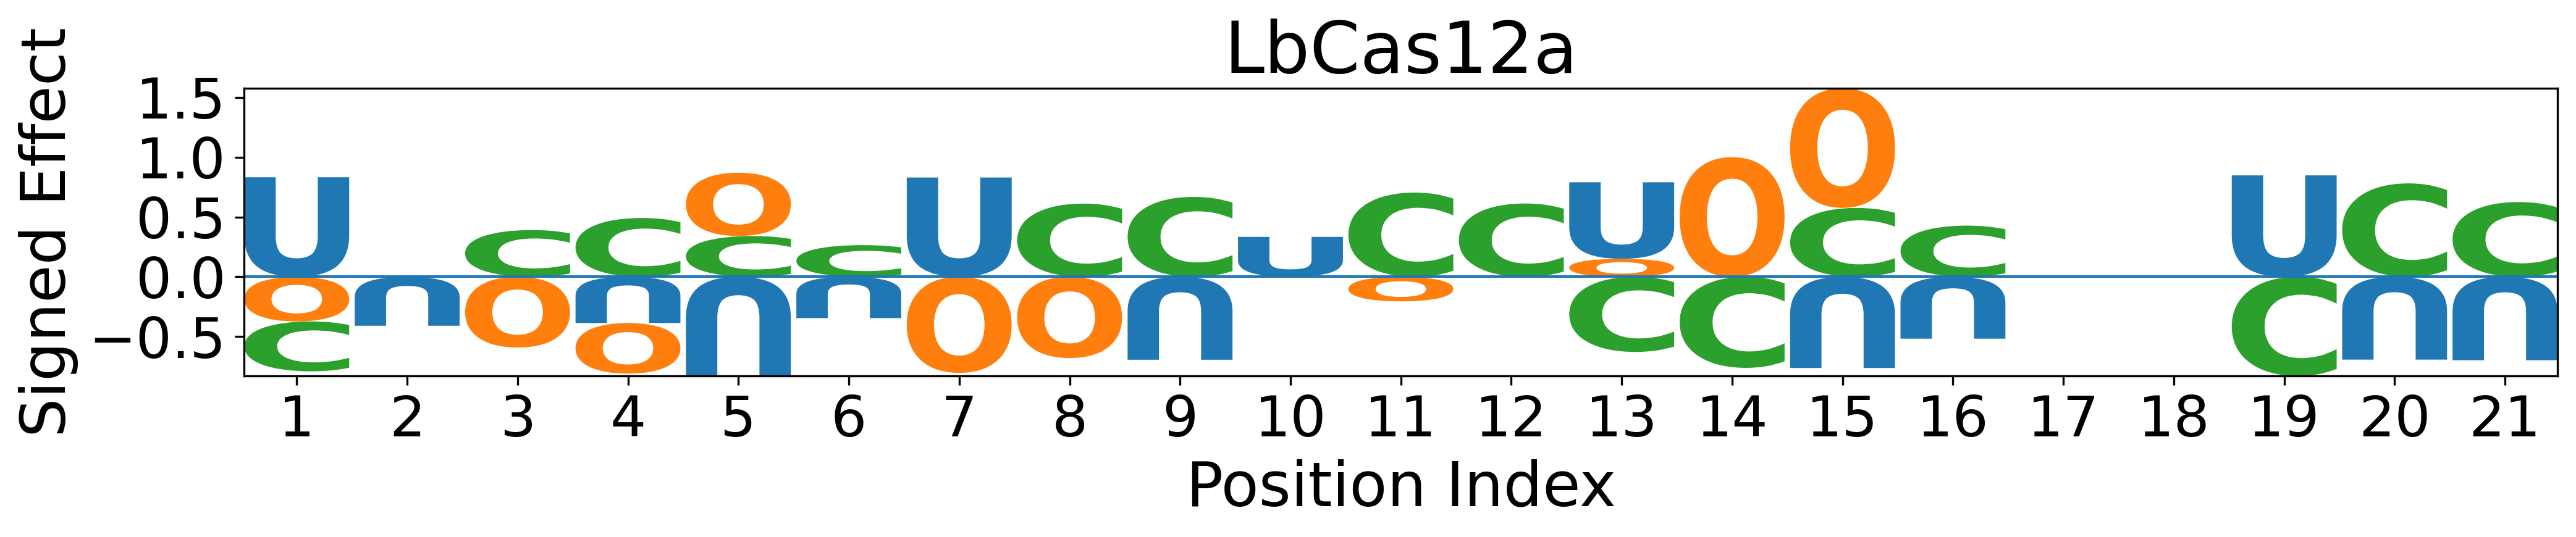

Saved to: LbCas12a_Specificity_model_computed_spearman_by_struct_position_spacer.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

STRUCT_MAP = {
    # common possibilities (edit to match your file):
    "Unpaired": "U",
    "Paired-Opening": "O",
    "Paired-Closing": "C"
}

def load_logo_matrix(csv_path, value_col="Median Spearman Correlation", pos_max=100):
    df = pd.read_csv(csv_path)
    df[['Pos', 'Raw']] = df['Feature'].str.extract(r'Pos(\d+)_(.+)')
    df['Pos'] = df['Pos'].astype(int)
    df["Raw"] = df["Raw"].astype(str).str.strip()
    # Map Raw token -> dot-paren symbol
    df["Struct"] = df["Raw"].map(STRUCT_MAP)
    mat = df.pivot(index="Struct", columns="Pos", values=value_col)
    mat = mat.reindex(columns=range(1, pos_max + 1))

    return mat

# ---- Load positive and negative matrices ----
pos_mat = load_logo_matrix("features_with_positive_IQR_Specificity_model_cnn2_Cas12a.csv")
neg_mat = load_logo_matrix("features_with_negative_IQR_Specificity_model_cnn2_Cas12a.csv")

# ---- Ensure consistent bases and positions ----
struct_order = ['C', 'O', 'U'] 
pos_mat = pos_mat.reindex(struct_order)
neg_mat = neg_mat.reindex(struct_order)

all_pos = sorted(set(pos_mat.columns).union(set(neg_mat.columns)))
pos_mat = pos_mat.reindex(columns=all_pos)
neg_mat = neg_mat.reindex(columns=all_pos)

# ---- Build signed matrix: positive above 0, negative below 0 ----
pos_vals = pos_mat.fillna(0.0)
neg_vals = neg_mat.fillna(0.0)
signed_mat = pos_vals + (-np.abs(neg_vals))  # keeps pos; makes neg go downward

# ---- PAM-proximity adjustment: reverse AND renumber ----
# Ensure numeric order first (important if columns are not strictly sorted)
signed_mat = signed_mat.reindex(sorted(signed_mat.columns), axis=1)

# 1) take the first 21 original positions
block20 = signed_mat.loc[:, list(range(22, 43))].copy()

# 3) relabel for PAM-proximal display: left→right becomes 1..21
block20.columns = range(1, 22)   # display index

signed_20 = block20

# Convert to logomaker format: rows=positions, cols=bases
logo_df = signed_20.T.copy()  # index=Pos, columns=bases

import logomaker
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

color_scheme = {
    "U": "#1f77b4",   # unpaired
    "O": "#ff7f0e",   # paired-opening
    "C": "#2ca02c",   # paired-closing
}

# ---- Plot signed logo ----
fig, ax = plt.subplots(figsize=(14, 3), dpi=300)

logomaker.Logo(
    logo_df,
    ax=ax,
    color_scheme=color_scheme,
    flip_below=True
)

# Zero baseline
ax.axhline(0, linewidth=1)

# X ticks start at 1 (display only)
n_pos = logo_df.shape[0]

ax.set_xticks(range(1, n_pos + 1))
ax.set_xticklabels(range(1, n_pos + 1), fontsize=22)

from matplotlib.ticker import MaxNLocator

ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(axis='y', labelsize=22)

ax.set_xlabel("Position Index", fontsize=24)
ax.set_ylabel("Signed Effect", fontsize=24)
ax.set_title("LbCas12a", fontsize=28)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

out_df = (
    signed_mat
    .reset_index()  # Base becomes a column
    .melt(id_vars="Struct", var_name="Position", value_name="Computed_Spearman")
)

# Ensure types
out_df["Position"] = out_df["Position"].astype(int)
out_df["Computed_Spearman"] = out_df["Computed_Spearman"].astype(float)

# Sign column (same style: positive / negative / zero)
out_df["Sign"] = np.where(
    out_df["Computed_Spearman"] > 0, "positive",
    np.where(out_df["Computed_Spearman"] < 0, "negative", "zero")
)

# Sort like a clean table: by Position then Base
struct_order = ['C', 'O', 'U']
out_df["Struct"] = pd.Categorical(out_df["Struct"], categories=struct_order, ordered=True)
out_df = out_df.sort_values(["Position", "Struct"]).reset_index(drop=True)

# Save
out_df.to_csv("LbCas12a_Specificity_model_computed_spearman_by_struct_position_spacer.csv", index=False)

# If you also want it as a Python list of dicts:
as_list = out_df.to_dict(orient="records")

print("Saved to: LbCas12a_Specificity_model_computed_spearman_by_struct_position_spacer.csv")

